# 01 – EDA: Multi-Source Road Surface Crack Detection Dataset

**CSE445 – Road Surface Crack Detection & Segmentation**

This notebook performs Exploratory Data Analysis (EDA) on the multi-source crack detection datasets:
1. **Close-Up Dataset** (`data/crack/closeup/`): High-contrast, macro asphalt cracks (Stage 1 pre-training)
2. **Dashcam / Drone Dataset** (`data/crack/dashcam/`): Wide-angle road inspection footage (Stage 2 fine-tuning)

### Goals:
- Validate image-mask pair alignment across both datasets
- Visualize crack overlays and compare crack widths
- Quantify class imbalance (crack % vs background %) between closeup and dashcam footage
- Generate deterministic train / val / test split manifests (`data/crack/splits/`)

In [1]:
# ── Environment setup ────────────────────────────────────────────────────
import sys, os
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

try:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO = '/content/drive/MyDrive/Road_Damage_Project'
    os.environ['RUN_ENV'] = 'colab'
except ImportError:
    REPO = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    os.environ['RUN_ENV'] = 'local'

if REPO not in sys.path:
    sys.path.insert(0, REPO)

print('Repo root:', REPO)

Repo root: d:\Road_Damage_Project


In [2]:
%load_ext autoreload
%autoreload 2
import importlib
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import config
import support.crack.preprocess as preprocess
importlib.reload(preprocess)
from support.crack.preprocess import find_image_mask_dirs, load_pairs, report_stats, split_dataset, save_splits

print('Crack Root Directory    :', config.CRACK_DIR)
print('Closeup Directory (S1)  :', config.CRACK_CLOSEUP_DIR)
print('Dashcam Directory (S2)  :', config.CRACK_DASHCAM_DIR)
print('Splits Output Directory :', config.CRACK_SPLIT_DIR)

Crack Root Directory    : D:\Road_Damage_Project\data\crack
Closeup Directory (S1)  : D:\Road_Damage_Project\data\crack\closeup
Dashcam Directory (S2)  : D:\Road_Damage_Project\data\crack\dashcam
Splits Output Directory : D:\Road_Damage_Project\data\crack\splits


---
## 1. Load and Pair Image-Mask Datasets

In [3]:
# 1. Load Close-Up Dataset (Stage 1)
closeup_pairs = []
c_dirs = find_image_mask_dirs(config.CRACK_CLOSEUP_DIR)
if c_dirs:
    closeup_pairs = load_pairs(c_dirs[0], c_dirs[1], tag='Closeup')

# 2. Load Dashcam Dataset (Stage 2)
dashcam_pairs = []
d_dirs = find_image_mask_dirs(config.CRACK_DASHCAM_DIR)
if d_dirs:
    dashcam_pairs = load_pairs(d_dirs[0], d_dirs[1], tag='Dashcam')
elif find_image_mask_dirs(config.CRACK_DIR):
    # Fallback to root data/crack/images and masks
    root_dirs = find_image_mask_dirs(config.CRACK_DIR)
    dashcam_pairs = load_pairs(root_dirs[0], root_dirs[1], tag='Dashcam/Default')

print(f'\n[Summary] Closeup pairs: {len(closeup_pairs)} | Dashcam pairs: {len(dashcam_pairs)}')

[Closeup] 11 images have no matching mask (skipped).
[Closeup] Loaded 3352 matched image-mask pairs from images/masks.
[Dashcam] Loaded 2832 matched image-mask pairs from images/masks.

[Summary] Closeup pairs: 3352 | Dashcam pairs: 2832


---
## 2. Class Imbalance & Resolution Analysis
We compare the foreground crack pixel ratio between close-up macro shots and wide-angle drone/dashcam shots.

In [4]:
def analyze_subset(pairs, name, n_sample=50):
    if not pairs:
        return None
    sample = pairs[:n_sample]
    fg_ratios, heights, widths = [], [], []
    for img_p, mask_p in sample:
        mask = cv2.imread(str(mask_p), cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            h, w = mask.shape[:2]
            heights.append(h)
            widths.append(w)
            fg_ratios.append((mask > 127).mean() * 100.0)
    return {
        'Dataset': name,
        'Total Pairs': len(pairs),
        'Sample Count': len(fg_ratios),
        'Avg Crack Area (%)': np.mean(fg_ratios),
        'Median Crack Area (%)': np.median(fg_ratios),
        'Min Resolution': f'{min(widths)}x{min(heights)}',
        'Max Resolution': f'{max(widths)}x{max(heights)}'
    }

stats = []
if closeup_pairs:
    stats.append(analyze_subset(closeup_pairs, 'Closeup (Stage 1)'))
if dashcam_pairs:
    stats.append(analyze_subset(dashcam_pairs, 'Dashcam (Stage 2)'))

df_stats = pd.DataFrame(stats)
print('\n' + '=' * 70)
print('  DATASET IMBALANCE & SCALE COMPARISON')
print('=' * 70)
print(df_stats.to_string(index=False))
print('=' * 70)


  DATASET IMBALANCE & SCALE COMPARISON
          Dataset  Total Pairs  Sample Count  Avg Crack Area (%)  Median Crack Area (%) Min Resolution Max Resolution
Closeup (Stage 1)         3352            50            3.590701               2.730638        448x448        448x448
Dashcam (Stage 2)         2832            50            0.494095               0.497082      3840x2160      3840x2160


---
## 3. Side-by-Side Visualizations (Image, Mask & Crack Overlay)


--- Sample Overlays: Closeup Dataset ---


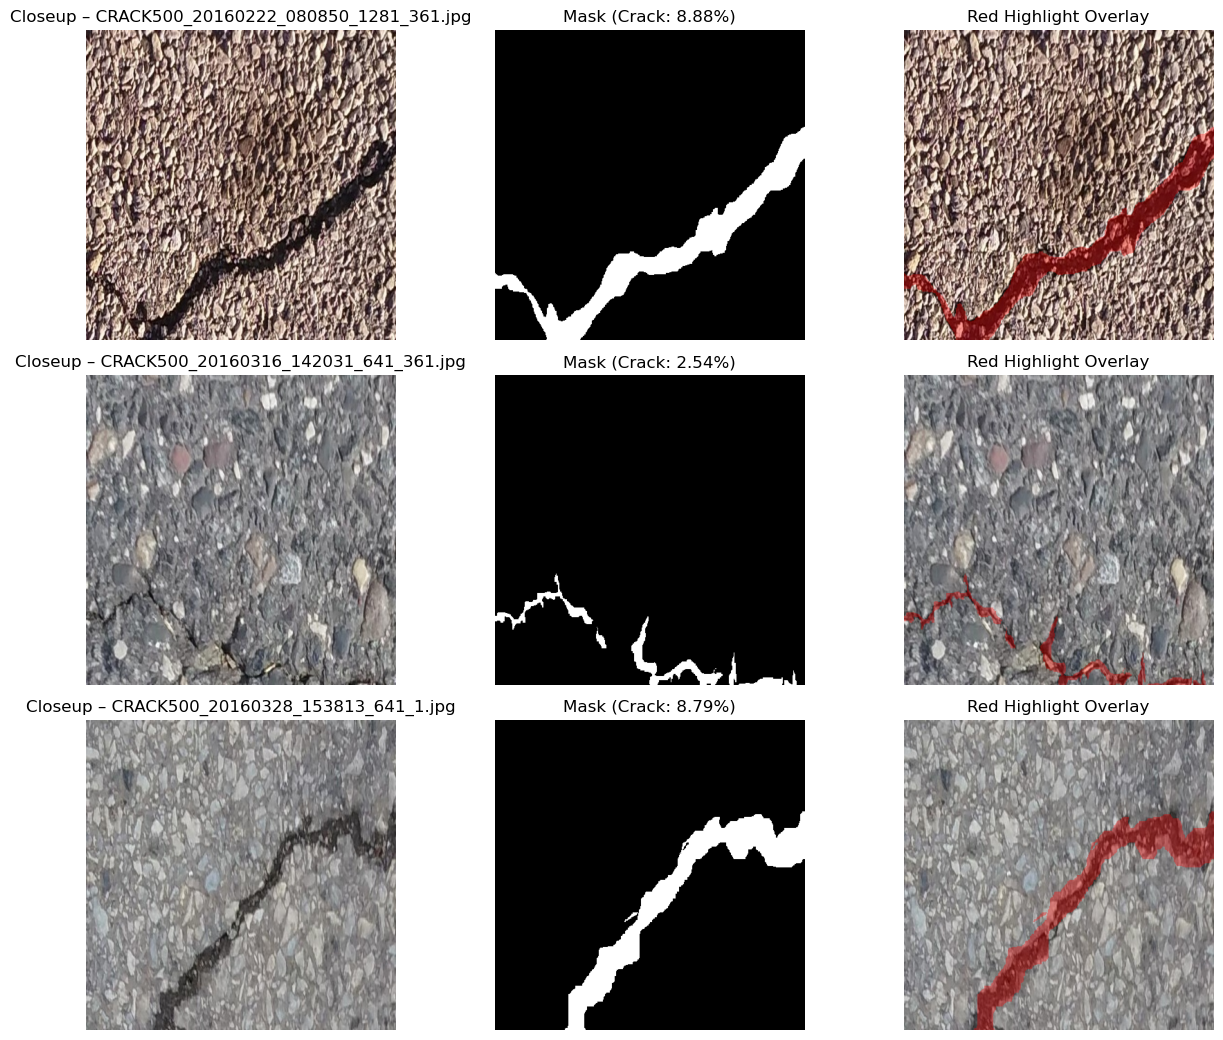


--- Sample Overlays: Dashcam / Drone Dataset ---


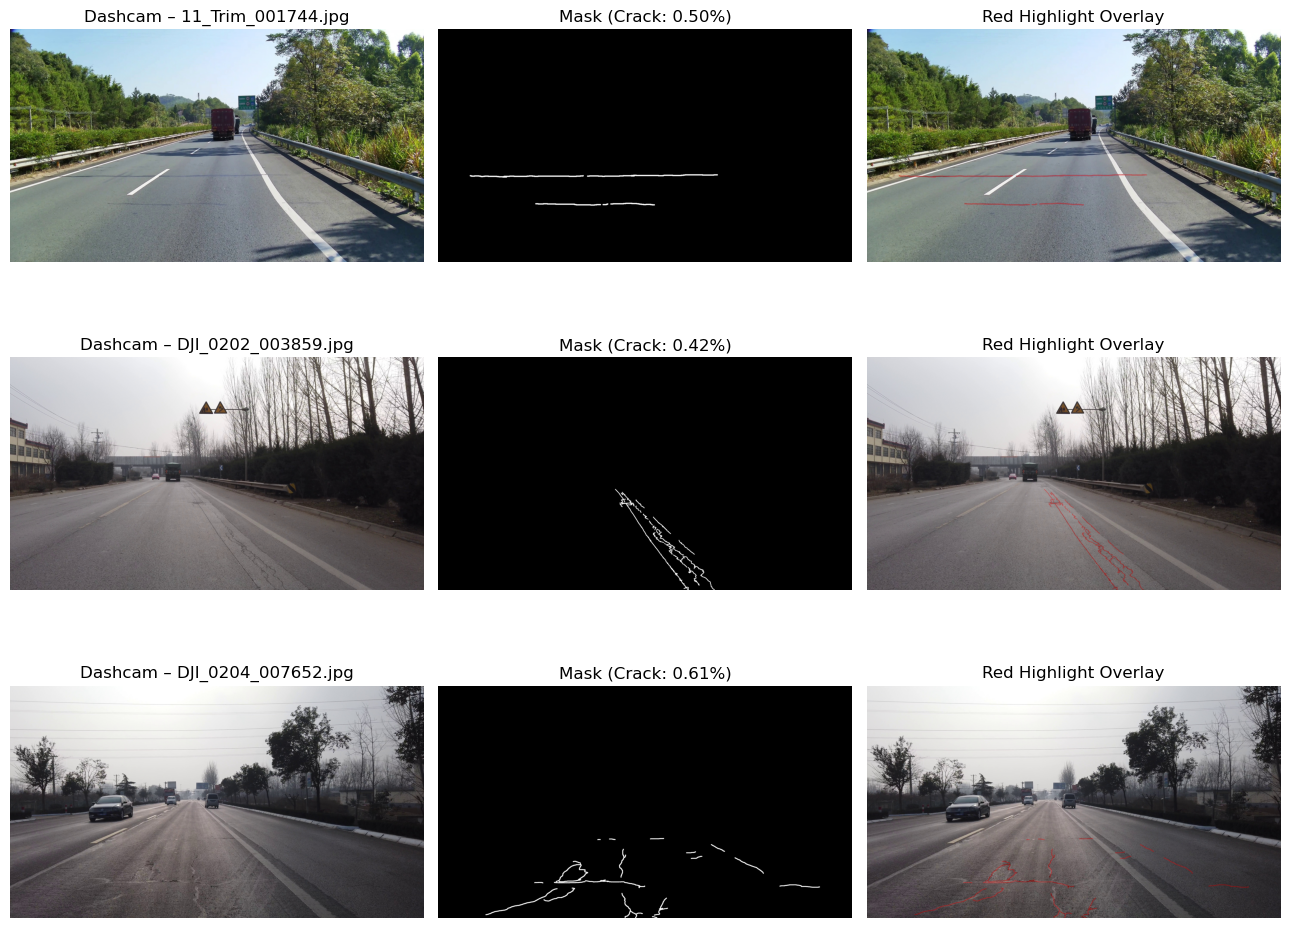

In [5]:
def plot_sample_overlays(pairs, title, n=4):
    if not pairs:
        return
    fig, axes = plt.subplots(n, 3, figsize=(13, 3.5 * n))
    step = max(1, len(pairs) // n)
    
    for i in range(n):
        img_p, mask_p = pairs[i * step]
        img = cv2.cvtColor(cv2.imread(str(img_p)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_p), cv2.IMREAD_GRAYSCALE)
        mask_bin = (mask > 127).astype(np.uint8)
        
        # Overlay (red on crack)
        overlay = img.copy()
        overlay[mask_bin > 0] = [255, 0, 0]
        blended = cv2.addWeighted(img, 0.65, overlay, 0.35, 0)
        
        # 1. Original Image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'{title} – {img_p.name}')
        axes[i, 0].axis('off')
        
        # 2. Mask
        axes[i, 1].imshow(mask_bin, cmap='gray')
        fg_pct = mask_bin.mean() * 100.0
        axes[i, 1].set_title(f'Mask (Crack: {fg_pct:.2f}%)')
        axes[i, 1].axis('off')
        
        # 3. Blended Overlay
        axes[i, 2].imshow(blended)
        axes[i, 2].set_title('Red Highlight Overlay')
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

if closeup_pairs:
    print('\n--- Sample Overlays: Closeup Dataset ---')
    plot_sample_overlays(closeup_pairs, 'Closeup', n=3)

if dashcam_pairs:
    print('\n--- Sample Overlays: Dashcam / Drone Dataset ---')
    plot_sample_overlays(dashcam_pairs, 'Dashcam', n=3)

---
## 4. Generate Deterministic Split Manifests
Writes `stage1_train.csv`, `train.csv`, `val.csv`, `test.csv`, and `combined_train.csv` into `data/crack/splits/`.

In [6]:
config.CRACK_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Split Closeup
if closeup_pairs:
    c_splits = split_dataset(closeup_pairs)
    save_splits(c_splits, prefix='stage1_')
    save_splits(c_splits, prefix='closeup_')

# 2. Split Dashcam
if dashcam_pairs:
    d_splits = split_dataset(dashcam_pairs)
    save_splits(d_splits, prefix='')           # train.csv, val.csv, test.csv
    save_splits(d_splits, prefix='dashcam_')

# 3. Combined Split
if closeup_pairs and dashcam_pairs:
    comb_splits = {
        'train': c_splits['train'] + d_splits['train'],
        'val'  : c_splits['val'] + d_splits['val'],
        'test' : d_splits['test']  # Target evaluation remains on real dashcam footage
    }
    save_splits(comb_splits, prefix='combined_')

print(f'\n[OK] All dataset split manifests successfully generated at: {config.CRACK_SPLIT_DIR}')

  train:  2346 pairs
    val:   502 pairs
   test:   504 pairs
  [OK] Saved stage1_train.csv     (2346 rows) -> stage1_train.csv
  [OK] Saved stage1_val.csv       ( 502 rows) -> stage1_val.csv
  [OK] Saved stage1_test.csv      ( 504 rows) -> stage1_test.csv
  [OK] Saved closeup_train.csv    (2346 rows) -> closeup_train.csv
  [OK] Saved closeup_val.csv      ( 502 rows) -> closeup_val.csv
  [OK] Saved closeup_test.csv     ( 504 rows) -> closeup_test.csv
  train:  1982 pairs
    val:   424 pairs
   test:   426 pairs
  [OK] Saved train.csv            (1982 rows) -> train.csv
  [OK] Saved val.csv              ( 424 rows) -> val.csv
  [OK] Saved test.csv             ( 426 rows) -> test.csv
  [OK] Saved dashcam_train.csv    (1982 rows) -> dashcam_train.csv
  [OK] Saved dashcam_val.csv      ( 424 rows) -> dashcam_val.csv
  [OK] Saved dashcam_test.csv     ( 426 rows) -> dashcam_test.csv
  [OK] Saved combined_train.csv   (4328 rows) -> combined_train.csv
  [OK] Saved combined_val.csv     ( 926 r